In [11]:
import numpy as np
import matplotlib.pyplot as plt
# Project Path Setup
from setup_project_path import (
    check_and_add_project_path,
)  # Script to check and add project path
check_and_add_project_path()
from src.AAA.aaa_algorithm import aaa, cleanup
from src.AAA.AAA_kernel import AAAKernel
from src.kernel_params.kernel_params import KernelParams
from scipy import integrate
from src.utils.common_funcs import initialize_fine_grid, set_time_grid
from src.spec_dens.spec_dens import spec_dens_gapless, spec_dens_semi_circle


In [12]:
#function that returns the spectral density
"""def spec_dens(omega):
    omega = np.asarray(omega)  # Ensure omega is a NumPy array
    result = np.zeros_like(omega)  # Initialize result array with the same shape as omega
    
    mask = np.abs(omega) < 1  # Boolean mask for values where abs(omega) < 1
    result[mask] = np.sqrt(1 - omega[mask]**2)  # Apply the formula only where the condition is True
    
    return result"""

spec_dens = lambda x: spec_dens_semi_circle(x, Gamma = 2, half_width=3)

#set parameters
params = KernelParams(spec_dens = spec_dens, n = 1000, m = 1000, N_max = 500, delta_t = 0.1, h = 0.01, beta = np.inf, phi = 0)

In [13]:
#explicitly get the fine frequency grid
fine_grid, _, _ = initialize_fine_grid(params.get_param("m"), params.get_param("n"), params.get_param("h"), freq_parametrization= "simple_exp")

# frequency points in for negativ and positive part on real axis
Z = np.concatenate((-fine_grid[::-1], fine_grid)) 

# function values, determined by product of spectral density and Fermi Dirac distribution and Jacobian factor h*abs(x)
def func_exact(x):
    f = spec_dens(x) * 1/(1 + np.exp(- params.get_param("beta") * x)) 
    f = np.where(np.isnan(f), 0, f)
    return f

F = func_exact(Z)



#perform AAA algorithm on spectral density multiplied with Fermi-Dirac distribution
r, errors = aaa(Z = Z, F = F, return_errors=True)
r = cleanup(r, Z, F)

#Frequency grids
print("\nFine grid (for positive frequencies):\n", "first five: ", fine_grid[:5], "\n last five: ", fine_grid[-5:])
print(Z)
#print the first 5 nodes
print("\nNodes: \n", r.nodes[:5])
#print the first 5 poles
print("\nPoles: \n", r.poles()[:5])
#print the first 5 weights
print("\n weights: \n", r.weights[:5])


#compute poles and residues
poles, residues = r.polres()




1 Froissart doublets

Fine grid (for positive frequencies):
 first five:  [4.53999298e-05 4.58562066e-05 4.63170692e-05 4.67825635e-05
 4.72527360e-05] 
 last five:  [21162.7957175  21375.48535043 21590.31254971 21807.29879823
 22026.46579481]
[-22026.46579481 -21807.29879823 -21590.31254971 ...  21590.31254971
  21807.29879823  22026.46579481]

Nodes: 
 [-2.05373406e+04  2.42966960e-03  4.58562066e-05  5.06789460e-05
  7.26396240e-05]

Poles: 
 [2.97433525+0.j         2.94463036+0.01028646j 2.94463036-0.01028646j
 2.92335719+0.04456271j 2.92335719-0.04456271j]

 weights: 
 [ 9.99996161e-01  5.41446306e-09 -4.92648473e-11  1.70463092e-10
  4.65620377e-10]


/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/src/AAA/aaa_algorithm.py:169: RuntimeWarning: divide by zero encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/src/AAA/aaa_algorithm.py:169: RuntimeWarning: invalid value encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/src/AAA/aaa_algorithm.py:172: RuntimeWarning: invalid value encountered in divide
  res = N_pol / Ddiff_pol


Text(0, 0.5, 'Spectral Density')

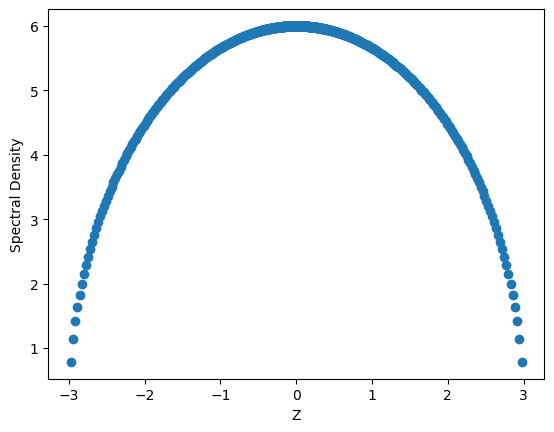

In [14]:
#plot the spectral density (omit the zeros in the plot)
plt.figure()
vals = spec_dens(Z)
mask = abs(vals) > 1e-10
plt.scatter(Z[mask], vals[mask])
plt.xlabel("Z")
plt.ylabel("Spectral Density")


/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_43809/3624335156.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  axs[0].plot(poles.real, poles.imag, 'ro', label = 'Poles', color = 'blue')


Text(0.0001, 0.01, 'nbr. Froisset doublets: 3\n[i.e. abs(residue_k) < 1e-13)]')

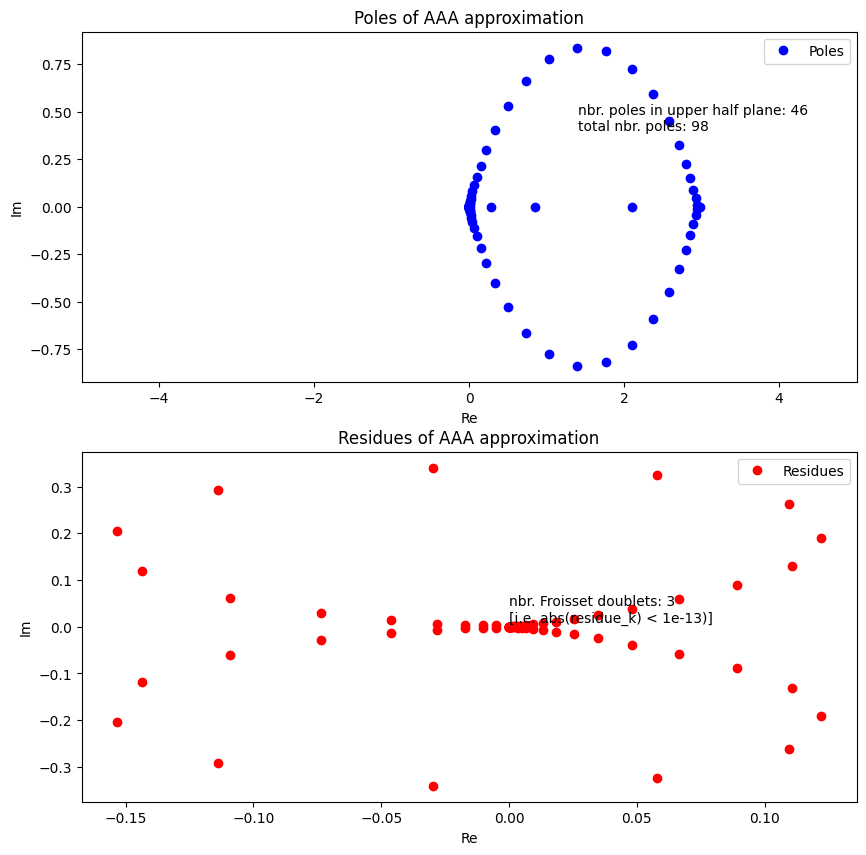

In [15]:
#plot the poles in the complex plane
#subplots in one figure
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
#plot the poles in the complex plane
axs[0].plot(poles.real, poles.imag, 'ro', label = 'Poles', color = 'blue')
axs[0].set_title('Poles of AAA approximation')
axs[0].legend()
axs[0].set_xlabel('Re')
axs[0].set_ylabel('Im')
axs[0].text(1.4,.4, 'nbr. poles in upper half plane: ' + str(len(poles[poles.imag > 0])) + '\n' + 'total nbr. poles: ' + str(len(poles)))
axs[0].set_xlim(-5,5)

#plot the residues in the complex plane
axs[1].plot(residues.real, residues.imag, 'ro', label = 'Residues')
axs[1].set_title('Residues of AAA approximation')
axs[1].legend()
axs[1].set_xlabel('Re')
axs[1].set_ylabel('Im')
#compute number of Froisset doubles:
nbr_doublets = np.sum(np.abs(abs(residues)) < 1e-10)
axs[1].text(.0001,.01, 'nbr. Froisset doublets: ' + str(nbr_doublets) + '\n' + '[i.e. abs(residue_k) < 1e-13)]')



Text(0, 0.5, 'Error')

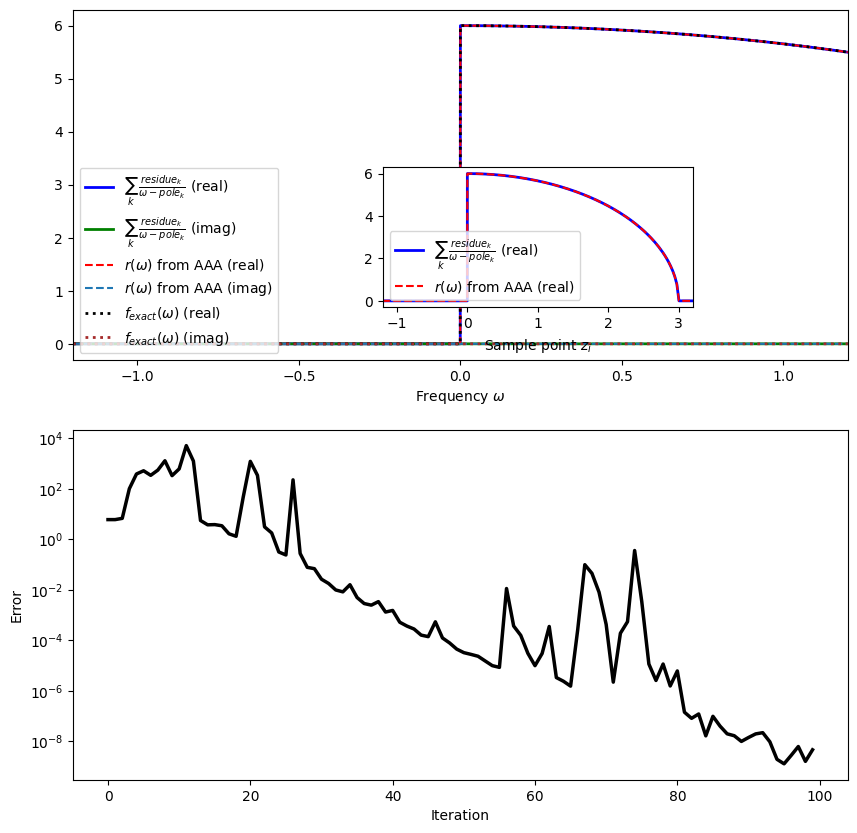

In [18]:
#check that sum over residues divided by poles gives r(z)

#define function as r_check(x) = sum_k residue_k / (x - pole_k)
r_check = lambda x: np.sum([res / (x - pole) for res, pole in zip(residues, poles)])

#range in which we want to plot the function
x_range = np.linspace(-1.2,1.2,10000)

#evaluate r_check(x) for each x in x_range
vals_residues = np.array([r_check(x) for x in x_range])
#evaluate func_exact(x) for each x in x_range
vals_exact = np.array([func_exact(x) for x in x_range])
#evaluate r(x) for each x in x_range
vals_rational = r(x_range)


#plot the real and imaginary part of r(x) and the real and imaginary part of r_check(x)
#figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

axs[0].plot(x_range, vals_residues.real, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (real)' , linewidth = 2, color = "blue")
axs[0].plot(x_range, vals_residues.imag, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (imag)' , linewidth = 2, color = "green")
axs[0].plot(x_range, vals_rational.real, label = r'$r(\omega)$' + ' from AAA (real)' , linestyle = '--', color = "red")
axs[0].plot(x_range, vals_rational.imag, label = r'$r(\omega)$' + ' from AAA (imag)' , linestyle = '--')
axs[0].plot(x_range, vals_exact.real, label = r'$f_{exact}(\omega)$' + ' (real)' , linestyle = 'dotted', linewidth = 2, color = "black")
axs[0].plot(x_range, vals_exact.imag, label = r'$f_{exact}(\omega)$' + ' (imag)' , linestyle = 'dotted', linewidth = 2, color = "brown")
axs[0].legend(loc = "lower left")
axs[0].set_xlabel('Frequency ' + r'$\omega$')
axs[0].set_xlim(-1.2,1.2)
#make inset plot
axins = axs[0].inset_axes([0.4, 0.15, 0.4, 0.4])
axins.plot(Z, np.array([r_check(z) for z in Z]).real, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (real)' , linewidth = 2, color = "blue")
axins.plot(Z, r(Z).real, label = r'$r(\omega)$' + ' from AAA (real)' , linestyle = '--', color = "red")
axins.set_xlim(-1.2,3.2)
axins.legend()
axins.set_xlabel('Sample point ' + r'$z_i$')


#plot the error as function of iteration
axs[1].plot(errors, label = 'Error', linewidth = 2.5, color = 'black')
axs[1].set_yscale('log')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Error')

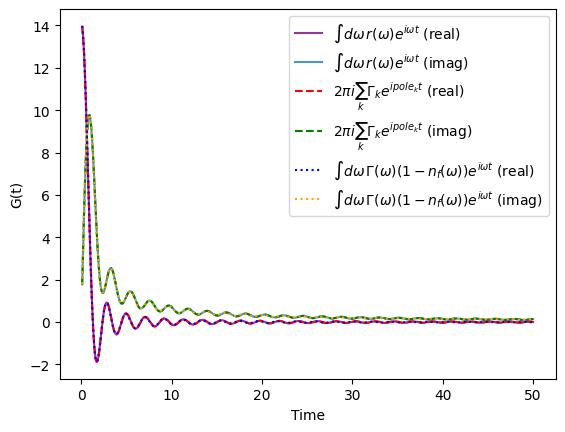

In [17]:
#compute the Green's function as contiuous integral

time_grid = set_time_grid(params.get_param("N_max"), params.get_param("delta_t"))

# Vectorized integration for real and imaginary parts
AAA_GF = np.array([integrate.quad_vec(
    lambda x: r(x) * np.exp(1.j * x * t),
    -np.inf,
    np.inf,
    epsabs=1.49e-2,
    epsrel=1.49e-2
) for t in time_grid])

exact_integral  = np.array([integrate.quad_vec(
    lambda x: spec_dens(x) * 1/(1 + np.exp(- params.get_param("beta") * x)) 
 * np.exp(1.j * x * t),
    -np.inf,
    np.inf,
    epsabs=1.49e-2,
    epsrel=1.49e-2
) for t in time_grid])


#check that "learned propagator is close to the reference propagator"
residues_upper = residues[poles.imag > 0]
poles_upper = poles[poles.imag > 0]


#sum over all modes
G_learned = 2.j * np.pi * np.sum(residues_upper  * np.exp(1.j * poles_upper * time_grid[:,np.newaxis]), axis=1)


#plot the learned propagator and the reference propagator

plt.plot(time_grid, AAA_GF[:,0].real, label=r'$\int d\omega \, r(\omega) e^{i\omega t} $' + ' (real)', color = 'purple', linestyle = '-', alpha = 0.8)
plt.plot(time_grid, AAA_GF[:,0].imag, label=r'$\int d\omega \, r(\omega) e^{i\omega t} $' + ' (imag)', linestyle = '-', alpha = 0.8)
plt.plot(time_grid, G_learned.real, label=r'$2\pi i \sum_k \Gamma_k e^{i pole_k t} $' + ' (real)', color = 'red', linestyle = '--')
plt.plot(time_grid, G_learned.imag, label=r'$2\pi i \sum_k \Gamma_k e^{i pole_k t} $' + ' (imag)', color = 'green', linestyle = '--')
plt.plot(time_grid, exact_integral[:,0].real, label=r'$\int d\omega \, \Gamma(\omega) (1-n_f(\omega)) e^{i\omega t} $' + ' (real)', color = 'blue', linestyle = 'dotted')
plt.plot(time_grid, exact_integral[:,0].imag, label=r'$\int d\omega \, \Gamma(\omega) (1-n_f(\omega)) e^{i\omega t} $' + ' (imag)', color = 'orange', linestyle = 'dotted')
       

plt.legend()
plt.xlabel('Time')
plt.ylabel('G(t)')
plt.show()
